In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Loading Data


In [ ]:
df = pd.read_csv("/content/loan_data.csv")

print(f"  Rows   : {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")
print(f"\n  Columns:\n  {list(df.columns)}\n")
print(df.head())

  Rows   : 9,578
  Columns: 14

  Columns:
  ['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']

   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        

Feature Transformation – Encoding Categorical Variables

In [ ]:
# Label-encode the 'purpose' column
le = LabelEncoder()
df['purpose_encoded'] = le.fit_transform(df['purpose'])
print(f"\n  Encoding map:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"    {cls:25s} → {idx}")

# One-hot encode (alternative / better for non-ordinal categories)
purpose_dummies = pd.get_dummies(df['purpose'], prefix='purpose', drop_first=True)
df = pd.concat([df, purpose_dummies], axis=1)
df.drop(columns=['purpose', 'purpose_encoded'], inplace=True)

print(f"\n  After one-hot encoding, shape: {df.shape}")
print(f"  New columns added: {list(purpose_dummies.columns)}")


  Encoding map:
    all_other                 → 0
    credit_card               → 1
    debt_consolidation        → 2
    educational               → 3
    home_improvement          → 4
    major_purchase            → 5
    small_business            → 6

  After one-hot encoding, shape: (9578, 19)
  New columns added: ['purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_small_business']


EXPLORATORY DATA ANALYSIS

In [ ]:
# Class distribution
print("\n Target Class Distribution")
target_counts = df['not.fully.paid'].value_counts()
print(f"       Fully Paid (0)   : {target_counts[0]:,} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"       Defaulted  (1)   : {target_counts[1]:,} ({target_counts[1]/len(df)*100:.1f}%)")
print(f"       Imbalance ratio  : {target_counts[0]/target_counts[1]:.1f}:1")


 Target Class Distribution
       Fully Paid (0)   : 8,045 (84.0%)
       Defaulted  (1)   : 1,533 (16.0%)
       Imbalance ratio  : 5.2:1


In [ ]:
# Basic statistics
print("\n  3.2  Descriptive Statistics")
print(df.describe().round(3).to_string())



  3.2  Descriptive Statistics
       credit.policy  int.rate  installment  log.annual.inc       dti      fico  days.with.cr.line    revol.bal  revol.util  inq.last.6mths  delinq.2yrs   pub.rec  not.fully.paid
count       9578.000  9578.000     9578.000        9578.000  9578.000  9578.000           9578.000     9578.000    9578.000        9578.000     9578.000  9578.000        9578.000
mean           0.805     0.123      319.089          10.932    12.607   710.846           4560.767    16913.964      46.799           1.577        0.164     0.062           0.160
std            0.396     0.027      207.071           0.615     6.884    37.971           2496.930    33756.190      29.014           2.200        0.546     0.262           0.367
min            0.000     0.060       15.670           7.548     0.000   612.000            178.958        0.000       0.000           0.000        0.000     0.000           0.000
25%            1.000     0.104      163.770          10.558     7.212   68

In [ ]:
# Missing values
print("\n  3.3  Missing Values")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("       No missing values found ✓")
else:
    print(missing[missing > 0])


  3.3  Missing Values
       No missing values found ✓


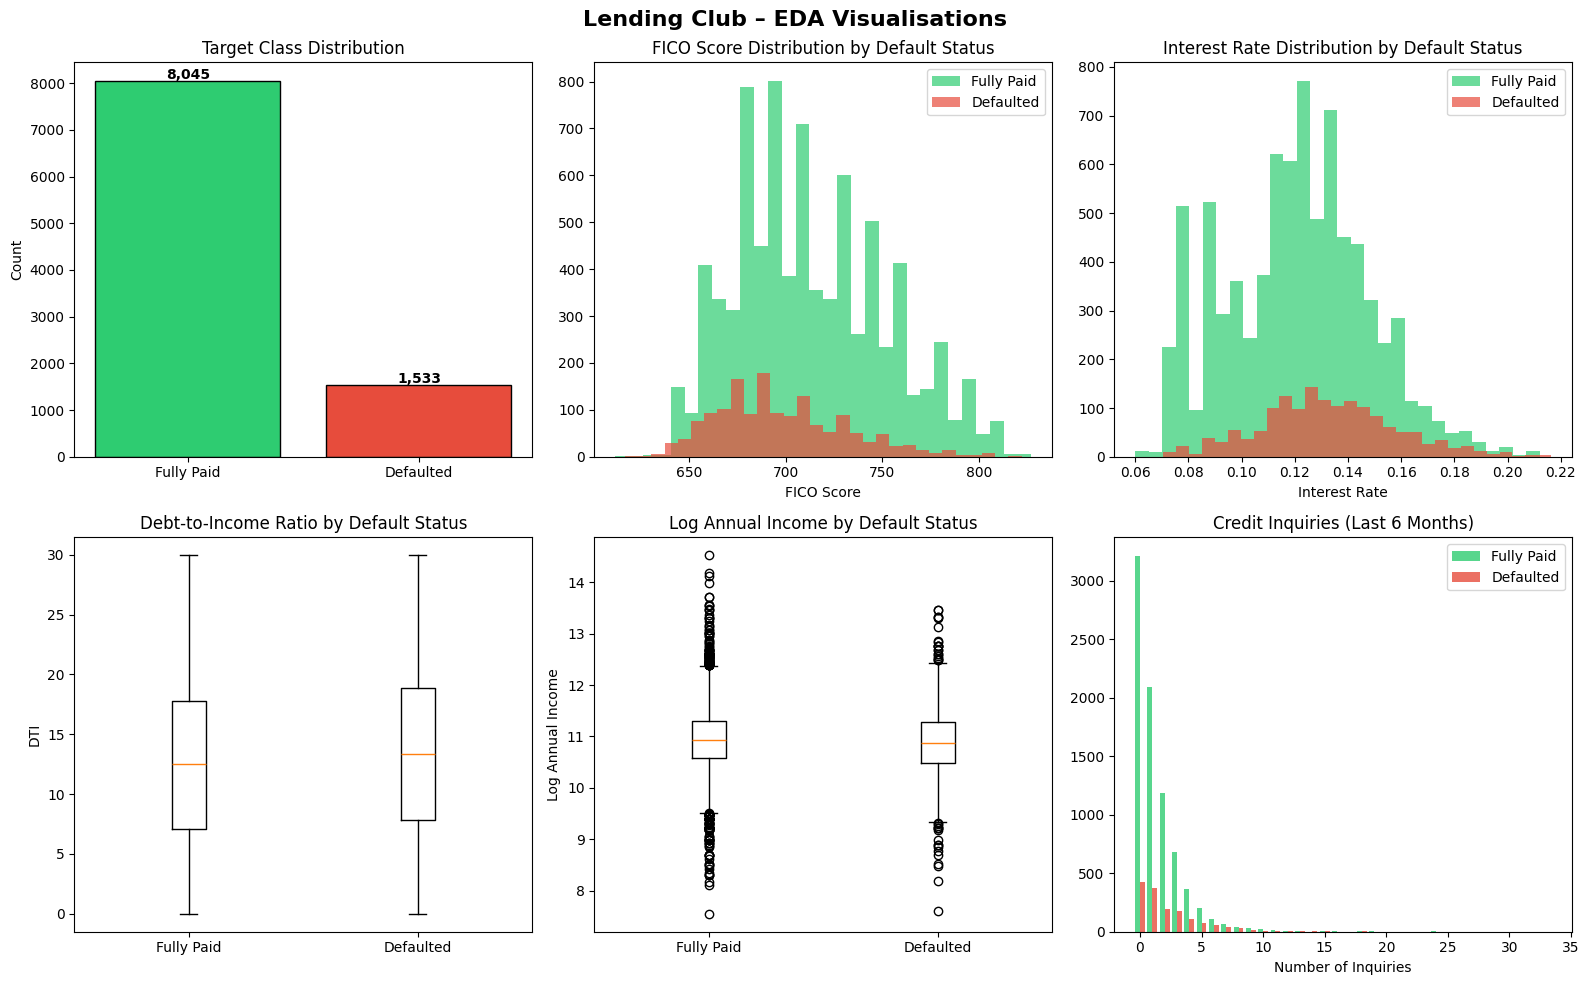

In [ ]:
# Visualisations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Lending Club – EDA Visualisations', fontsize=16, fontweight='bold')

# Plot 1 – Target distribution
axes[0, 0].bar(['Fully Paid', 'Defaulted'],
               [target_counts[0], target_counts[1]],
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 0].set_title('Target Class Distribution')
axes[0, 0].set_ylabel('Count')
for bar, count in zip(axes[0, 0].patches, [target_counts[0], target_counts[1]]):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 50,
                    f'{count:,}', ha='center', fontsize=10, fontweight='bold')

# Plot 2 – FICO score by default status
axes[0, 1].hist(df[df['not.fully.paid'] == 0]['fico'],
                bins=30, alpha=0.7, label='Fully Paid', color='#2ecc71')
axes[0, 1].hist(df[df['not.fully.paid'] == 1]['fico'],
                bins=30, alpha=0.7, label='Defaulted', color='#e74c3c')
axes[0, 1].set_title('FICO Score Distribution by Default Status')
axes[0, 1].set_xlabel('FICO Score')
axes[0, 1].legend()

# Plot 3 – Interest rate by default
axes[0, 2].hist(df[df['not.fully.paid'] == 0]['int.rate'],
                bins=30, alpha=0.7, label='Fully Paid', color='#2ecc71')
axes[0, 2].hist(df[df['not.fully.paid'] == 1]['int.rate'],
                bins=30, alpha=0.7, label='Defaulted', color='#e74c3c')
axes[0, 2].set_title('Interest Rate Distribution by Default Status')
axes[0, 2].set_xlabel('Interest Rate')
axes[0, 2].legend()

# Plot 4 – DTI distribution
axes[1, 0].boxplot([df[df['not.fully.paid'] == 0]['dti'],
                    df[df['not.fully.paid'] == 1]['dti']],
                   labels=['Fully Paid', 'Defaulted'])
axes[1, 0].set_title('Debt-to-Income Ratio by Default Status')
axes[1, 0].set_ylabel('DTI')

# Plot 5 – Log Annual Income
axes[1, 1].boxplot([df[df['not.fully.paid'] == 0]['log.annual.inc'],
                    df[df['not.fully.paid'] == 1]['log.annual.inc']],
                   labels=['Fully Paid', 'Defaulted'])
axes[1, 1].set_title('Log Annual Income by Default Status')
axes[1, 1].set_ylabel('Log Annual Income')

# Plot 6 – Inquiries last 6 months
inq_counts_paid     = df[df['not.fully.paid'] == 0]['inq.last.6mths'].value_counts().sort_index()
inq_counts_default  = df[df['not.fully.paid'] == 1]['inq.last.6mths'].value_counts().sort_index()
axes[1, 2].bar(inq_counts_paid.index - 0.2,   inq_counts_paid.values,
               width=0.4, label='Fully Paid', color='#2ecc71', alpha=0.8)
axes[1, 2].bar(inq_counts_default.index + 0.2, inq_counts_default.values,
               width=0.4, label='Defaulted',  color='#e74c3c', alpha=0.8)
axes[1, 2].set_title('Credit Inquiries (Last 6 Months)')
axes[1, 2].set_xlabel('Number of Inquiries')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

Feature Engineering – Correlation Analysis & Selection

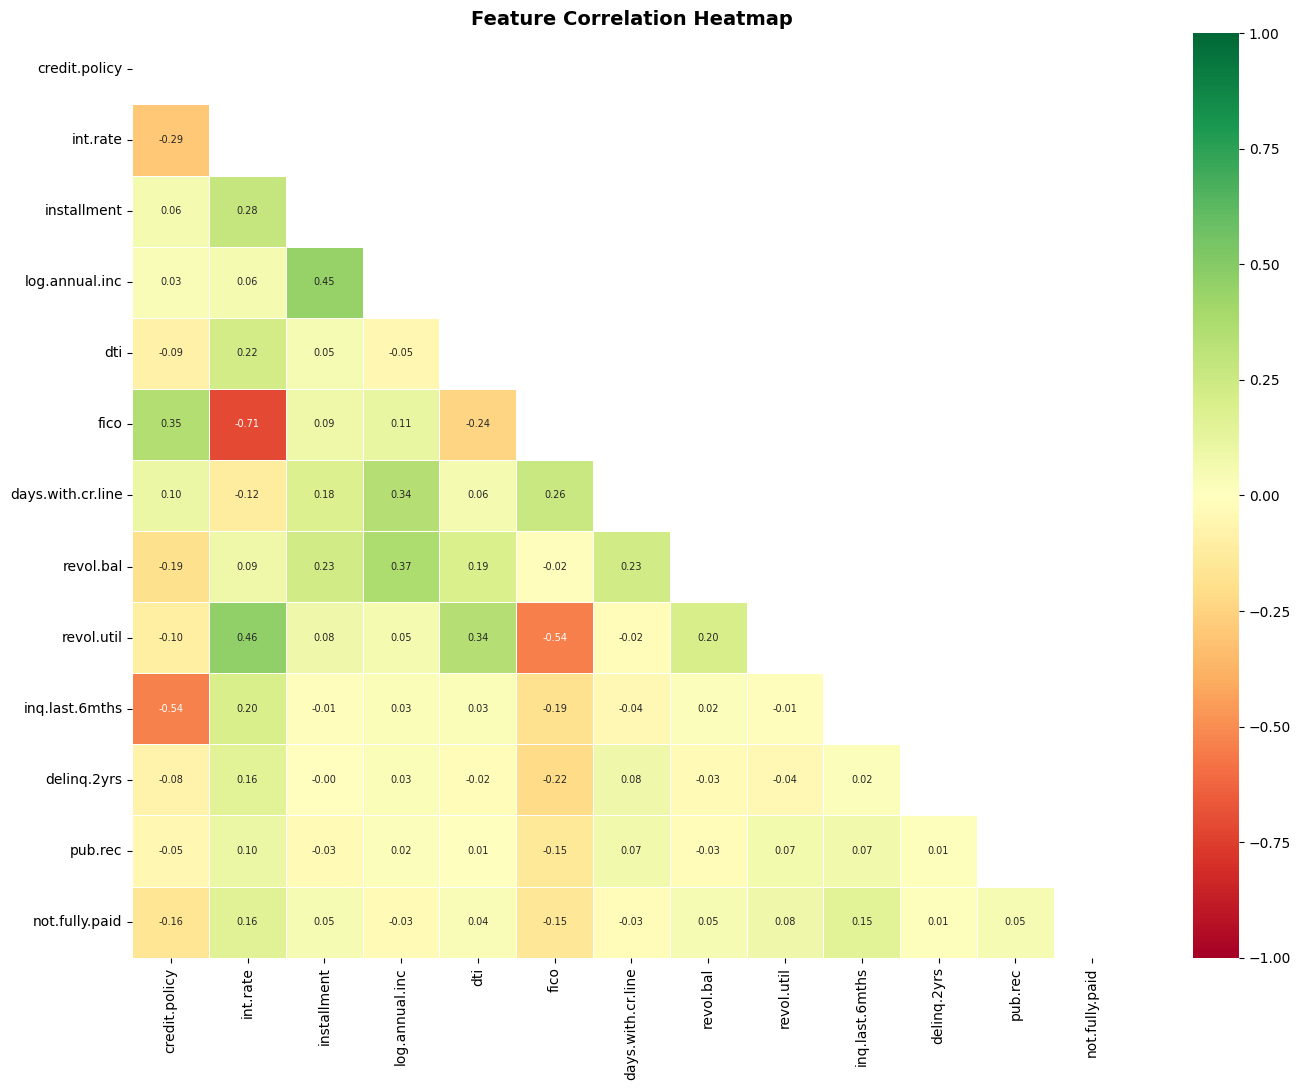

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1,
            annot_kws={'size': 7}, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Identify highly correlated pairs (|r| > 0.75, excluding self-correlations)
print("\n  Highly correlated feature pairs (|r| > 0.75):")
threshold   = 0.75
high_corr   = set()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
found_any   = False
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if abs(val) > threshold and row != 'not.fully.paid' and col != 'not.fully.paid':
            print(f"    {row:30s} ↔ {col:30s}  r = {val:.3f}")
            high_corr.add(col)   # drop the second of each correlated pair
            found_any = True

if not found_any:
    print("    No feature pairs exceed the threshold.")
    high_corr = set()


  Highly correlated feature pairs (|r| > 0.75):
    No feature pairs exceed the threshold.


In [ ]:
# Drop highly correlated features (if any)
if high_corr:
    print(f"\n  Dropping features: {high_corr}")
    df.drop(columns=list(high_corr), inplace=True)
else:
    print("\n  No features dropped – all correlations are within acceptable range.")

print(f"\n  Final feature set ({df.shape[1]-1} features):")
feature_cols = [c for c in df.columns if c != 'not.fully.paid']
for i, col in enumerate(feature_cols, 1):
    print(f"    {i:2d}. {col}")


  No features dropped – all correlations are within acceptable range.

  Final feature set (18 features):
     1. credit.policy
     2. int.rate
     3. installment
     4. log.annual.inc
     5. dti
     6. fico
     7. days.with.cr.line
     8. revol.bal
     9. revol.util
    10. inq.last.6mths
    11. delinq.2yrs
    12. pub.rec
    13. purpose_credit_card
    14. purpose_debt_consolidation
    15. purpose_educational
    16. purpose_home_improvement
    17. purpose_major_purchase
    18. purpose_small_business


Data Preparation for Modeling

In [ ]:
X = df.drop(columns=['not.fully.paid'])
y = df['not.fully.paid']

# Ensure all columns are numeric
X = X.astype(float)

print(f"\n  Feature matrix shape : {X.shape}")
print(f"  Target vector shape  : {y.shape}")

# Train/Validation/Test split  (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\n  Train set   : {X_train.shape[0]:,} rows")
print(f"  Val set     : {X_val.shape[0]:,}   rows")
print(f"  Test set    : {X_test.shape[0]:,}   rows")

# Standardise features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Compute class weights to handle imbalance
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f"\n  Class weights  : {class_weight_dict}")


  Feature matrix shape : (9578, 18)
  Target vector shape  : (9578,)

  Train set   : 6,704 rows
  Val set     : 1,437   rows
  Test set    : 1,437   rows

  Class weights  : {0: np.float64(0.5952761498845676), 1: np.float64(3.123951537744641)}


Building Deep Learning Model with Keras + TensorFlow

In [ ]:
n_features = X_train_sc.shape[1]

def build_model(n_features: int) -> keras.Model:
    """
    3-hidden-layer Feed-Forward Neural Network with:
      • Batch Normalisation for training stability
      • Dropout for regularisation
      • L2 kernel regularisation
      • Binary cross-entropy loss
    """
    model = keras.Sequential([
        # Input
        layers.Input(shape=(n_features,)),

        # Hidden Layer 1
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),

        # Hidden Layer 2
        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Hidden Layer 3
        layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Output – sigmoid for binary classification
        layers.Dense(1, activation='sigmoid')
    ], name='LoanDefaultNet')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            'accuracy'
        ]
    )
    return model

model = build_model(n_features)
model.summary()


Model: "LoanDefaultNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,249 (51.75 KB)

 Non-trainable params: 448 (1.75 KB)

Training

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=15, restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max',
        factor=0.5, patience=7,
        min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\n  Training completed in {len(history.history['loss'])} epochs.")


Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5874 - auc: 0.5957 - loss: 0.7394 - precision: 0.1997 - recall: 0.5247 - val_accuracy: 0.6708 - val_auc: 0.6713 - val_loss: 0.6630 - val_precision: 0.2594 - val_recall: 0.5696 - learning_rate: 0.0010
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5905 - auc: 0.6290 - loss: 0.7001 - precision: 0.2143 - recall: 0.5843 - val_accuracy: 0.6521 - val_auc: 0.6715 - val_loss: 0.6553 - val_precision: 0.2518 - val_recall: 0.5957 - learning_rate: 0.0010
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5940 - auc: 0.6359 - loss: 0.6897 - precision: 0.2189 - recall: 0.5983 - val_accuracy: 0.6667 - val_auc: 0.6761 - val_loss: 0.6441 - val_precision: 0.2544 - val_recall: 0.5609 - learning_rate: 0.0010
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5965 - auc: 0.6518 - loss: 0.6752 - precision: 0.2230 - recall: 0.6123 - val_accuracy: 0.6521 - val_auc: 0.6748 - val_loss: 0.6461 

Training & Validation Curves

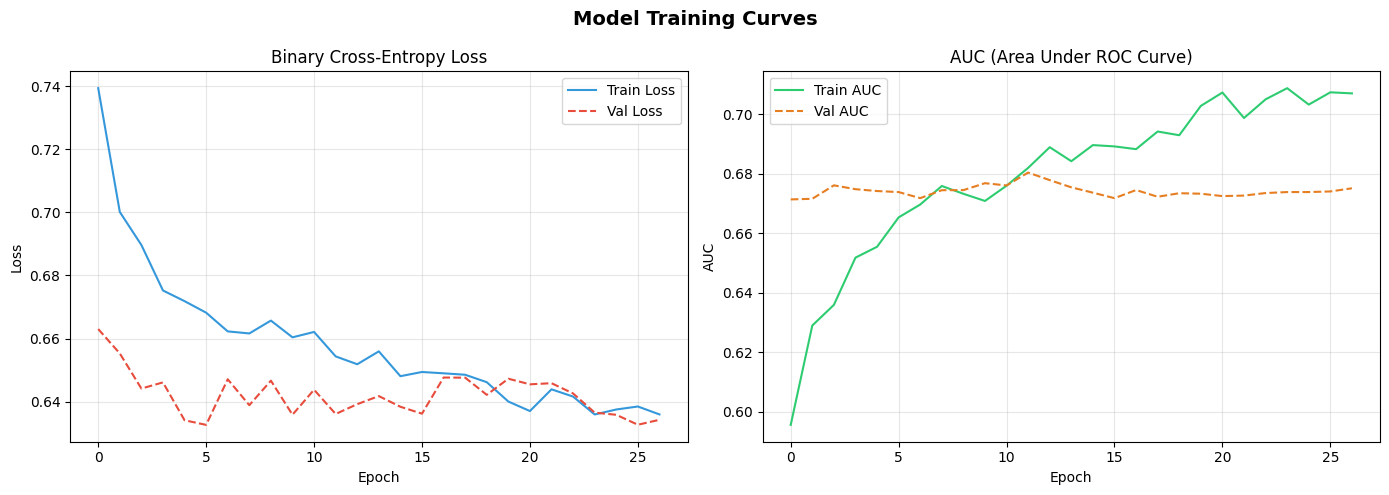

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linestyle='--')
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(history.history['auc'],     label='Train AUC', color='#2ecc71')
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='#e67e22', linestyle='--')
axes[1].set_title('AUC (Area Under ROC Curve)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Model Evaluation on Hold-Out Test Set


  Optimal decision threshold : 0.56
  Test Accuracy              : 74.32%
  ROC-AUC Score              : 0.6770

  Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.88      0.80      0.84      1207
   Defaulted       0.30      0.44      0.36       230

    accuracy                           0.74      1437
   macro avg       0.59      0.62      0.60      1437
weighted avg       0.79      0.74      0.76      1437



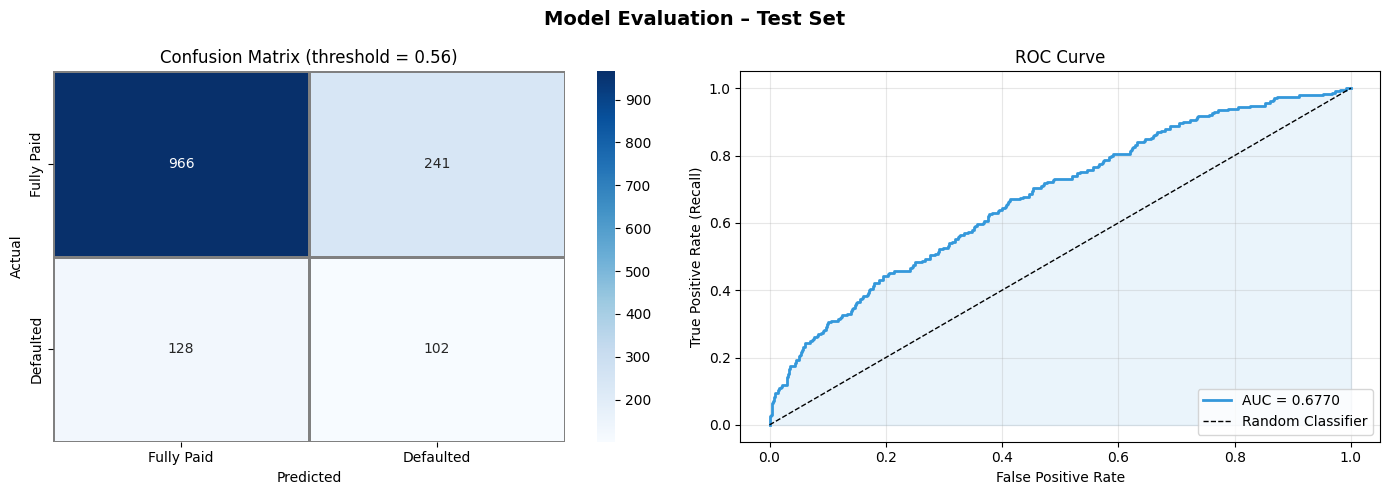

In [ ]:
y_pred_prob = model.predict(X_test_sc, verbose=0).ravel()

# Choose threshold that maximises F1 for minority class
from sklearn.metrics import f1_score
thresholds   = np.arange(0.1, 0.9, 0.01)
f1_scores    = [f1_score(y_test, (y_pred_prob >= t).astype(int), pos_label=1)
                for t in thresholds]
best_thresh  = thresholds[np.argmax(f1_scores)]
y_pred_class = (y_pred_prob >= best_thresh).astype(int)

print(f"\n  Optimal decision threshold : {best_thresh:.2f}")
print(f"  Test Accuracy              : {accuracy_score(y_test, y_pred_class)*100:.2f}%")
print(f"  ROC-AUC Score              : {roc_auc_score(y_test, y_pred_prob):.4f}")

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_class,
                             target_names=['Fully Paid', 'Defaulted']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation – Test Set', fontsize=14, fontweight='bold')

# Plot 1 – Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fully Paid', 'Defaulted'],
            yticklabels=['Fully Paid', 'Defaulted'],
            ax=axes[0], linewidths=1, linecolor='gray')
axes[0].set_title(f'Confusion Matrix (threshold = {best_thresh:.2f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 – ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



Feature Importance (Permutation-Based)


  Feature Importances (AUC drop when permuted):
                   Feature  Importance (AUC drop)
            inq.last.6mths               0.026101
                      fico               0.024045
            log.annual.inc               0.021818
                  int.rate               0.020637
purpose_debt_consolidation               0.017294
               installment               0.016916
             credit.policy               0.016401
       purpose_credit_card               0.008984
    purpose_small_business               0.008908
         days.with.cr.line               0.007593
                   pub.rec               0.006484
               delinq.2yrs               0.005897
       purpose_educational               0.002525
                       dti               0.001462
                revol.util              -0.000166
  purpose_home_improvement              -0.000378
                 revol.bal              -0.001686
    purpose_major_purchase              -0.002907


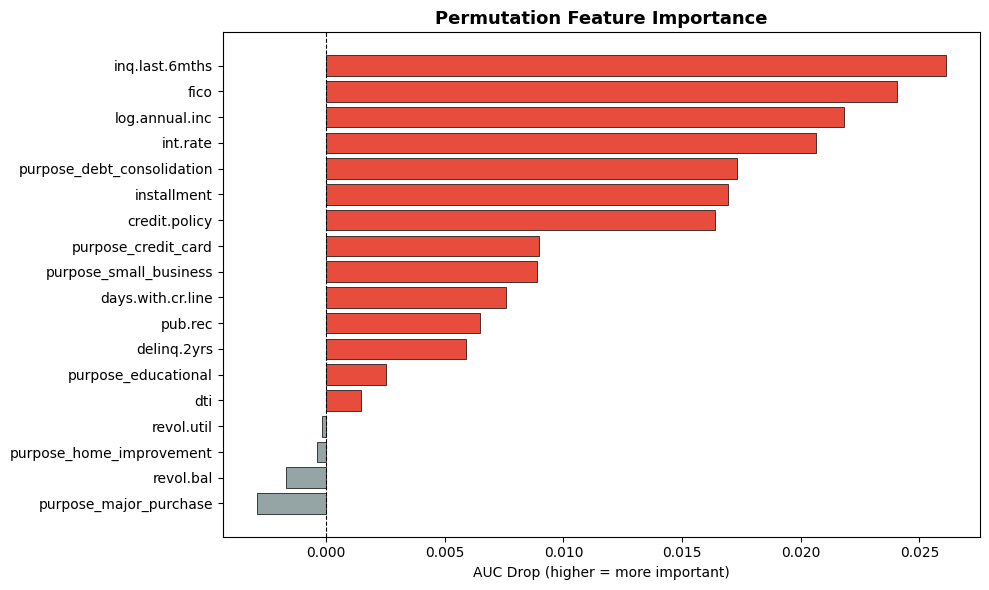

In [ ]:
base_auc = roc_auc_score(y_val, model.predict(X_val_sc, verbose=0).ravel())
importance = {}
for i, col in enumerate(X.columns):
    X_perm = X_val_sc.copy()
    np.random.shuffle(X_perm[:, i])
    perm_auc = roc_auc_score(y_val, model.predict(X_perm, verbose=0).ravel())
    importance[col] = base_auc - perm_auc

imp_df = (pd.Series(importance)
          .sort_values(ascending=False)
          .reset_index())
imp_df.columns = ['Feature', 'Importance (AUC drop)']
print("\n  Feature Importances (AUC drop when permuted):")
print(imp_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in imp_df['Importance (AUC drop)']]
plt.barh(imp_df['Feature'][::-1],
         imp_df['Importance (AUC drop)'][::-1],
         color=colors[::-1], edgecolor='black', linewidth=0.5)
plt.xlabel('AUC Drop (higher = more important)')
plt.title('Permutation Feature Importance', fontsize=13, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()



Saving Model

In [ ]:
model.save('loan_default_model.keras')
print("  Model saved -> loan_default_model.keras")

FINAL SUMMARY

In [ ]:
tn, fp, fn, tp = cm.ravel()
print(f"\n  Dataset                  : 9,578 loans (2007-2015)")
print(f"  Features used            : {X.shape[1]}")
print(f"  Architecture             : 3-layer DNN (128→64→32→1)")
print(f"  Imbalance handling       : Class weighting + threshold tuning")
print(f"\n Test Set Results")
print(f"  Accuracy                 : {accuracy_score(y_test, y_pred_class)*100:.2f}%")
print(f"  ROC-AUC                  : {auc_score:.4f}")
print(f"  True Positives  (caught defaults)     : {tp}")
print(f"  False Negatives (missed defaults)     : {fn}")
print(f"  True Negatives  (correct approvals)   : {tn}")
print(f"  False Positives (incorrect rejections): {fp}")



  Dataset                  : 9,578 loans (2007-2015)
  Features used            : 18
  Architecture             : 3-layer DNN (128→64→32→1)
  Imbalance handling       : Class weighting + threshold tuning

 Test Set Results
  Accuracy                 : 74.32%
  ROC-AUC                  : 0.6770
  True Positives  (caught defaults)     : 102
  False Negatives (missed defaults)     : 128
  True Negatives  (correct approvals)   : 966
  False Positives (incorrect rejections): 241
